In [1]:
from transformers import GPT2LMHeadModel

In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") #124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [ ]:
# transformer.wte.weight torch.Size([50257, 768]) #token embedding
# 50257 gpt vocab, token, 
# 768 n_embd

# transformer.wpe.weight torch.Size([1024, 768]) #pos
# block_size = 1024

In [3]:
sd_hf['transformer.wte.weight'].view(-1)[:20]

tensor([-0.1101, -0.0393,  0.0331,  0.1338, -0.0485, -0.0789, -0.2398, -0.0895,
         0.0253, -0.1074, -0.1811, -0.0672,  0.0739, -0.0161,  0.0117,  0.1245,
        -0.0020, -0.0815,  0.0338,  0.2365])

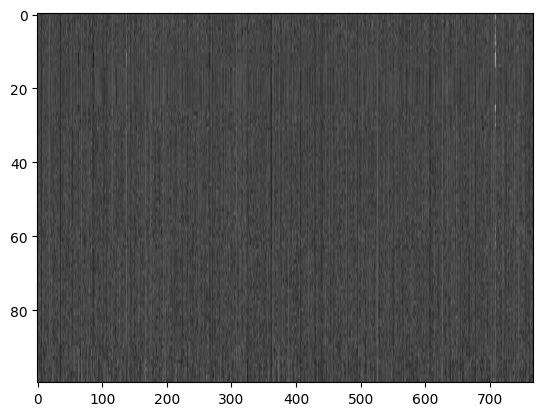

In [ ]:
import matplotlib.pyplot as plt


plt.imshow(sd_hf['transformer.wte.weight'][:100], cmap='gray', aspect='auto') #the 100th token embedding 

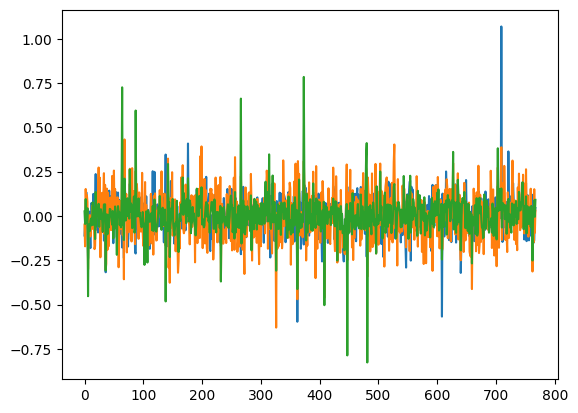

In [ ]:
plt.plot(sd_hf['transformer.wte.weight'][0,:]) #the vector of the first token
plt.plot(sd_hf['transformer.wte.weight'][100,:])
plt.plot(sd_hf['transformer.wte.weight'][200,:])

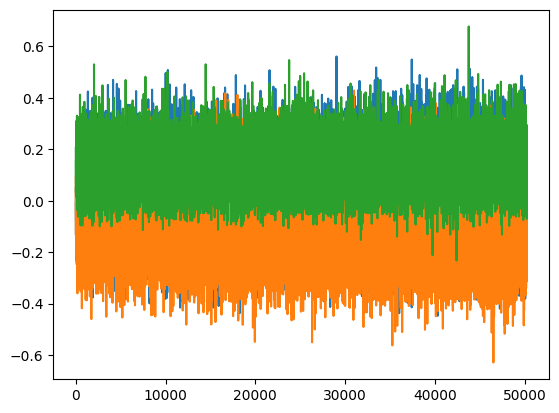

In [15]:
plt.plot(sd_hf['transformer.wte.weight'][:, 150]) #the 150th channel
plt.plot(sd_hf['transformer.wte.weight'][:, 200])
plt.plot(sd_hf['transformer.wte.weight'][:, 250])



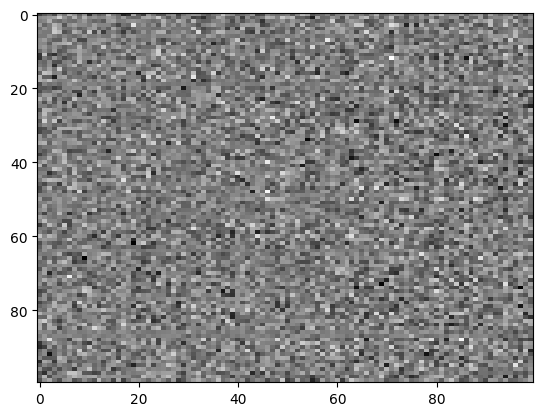

In [19]:
plt.imshow(sd_hf['transformer.h.0.attn.c_attn.weight'][:100,:100], cmap='gray', aspect='auto')

In [29]:
from transformers import pipeline, set_seed
generator = pipeline("text-generation", model='gpt2')
set_seed(1221)

print()
print(generator("Hello!", max_length=30, num_return_sequences=1)[0]['generated_text'])


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



Hello! You really're a nice, kind, cool guy!"

Wynny rolled forward slightly, pulling another glass of whiskey from her v
